In [18]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [20]:
data = pd.read_csv('c:/data/test/knn_class.csv')
data.head()

,age,income,score,target
0,22,1800,40,0
1,24,1900,42,0
2,26,2100,48,0
3,28,2300,50,0
4,29,2400,52,0


In [13]:
X = data.drop(columns = ['target'])
y = data['target']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [16]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
# 검증용 데이터에는 fit(학습)은 절대 하면안됨->데이터누수발생

best_k = None
best_acc = -1

for k in range(1,10,2):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)

    pred = model.predict(X_test_s)
    acc = accuracy_score(y_test,pred)
    print(f'k={k:2d} accuracy={acc:.4f}')

    if acc > best_acc:
        best_acc = acc
        best_k = k

print('\nbest_k=', best_k)
print('best_accuracy=', best_acc)

k= 1 accuracy=0.4444
k= 3 accuracy=0.6667
k= 5 accuracy=0.7778
k= 7 accuracy=0.7778
k= 9 accuracy=0.7778

best_k= 5
best_accuracy= 0.7777777777777778


In [17]:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_s, y_train)
final_pred = final_model.predict(X_test_s)

print('Accuracy:', accuracy_score(y_test, final_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, final_pred))

Accuracy: 0.7777777777777778
Confusion Matrix:
 [[3 1]
 [1 4]]


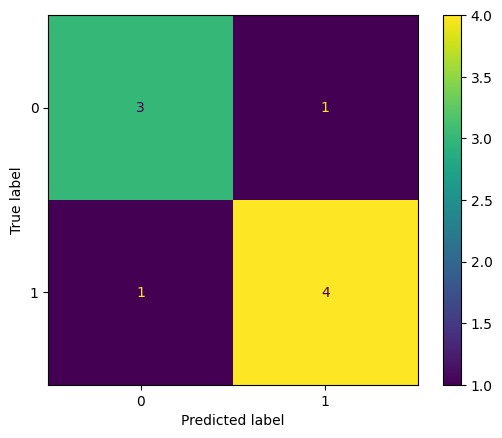

In [19]:
ConfusionMatrixDisplay(confusion_matrix(y_test, final_pred),display_labels=list(final_model.classes_)).plot()